# Mid-Term Project: End-to-End Machine Learning Pipeline
## Task: Titanic Passenger Survival (Binary Classification)

**Student ID:** 202689001  
**Submission Deadline:** 2026/05/22

---

## 1. Data Loading & Exploration (20 pts)

- Load the dataset into a Pandas DataFrame
- Show `shape`, `dtypes`, `head()`, and `describe()`
- Identify and visualise missing values
- Plot at least **3 meaningful charts**
- Summarise key observations

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report,
    roc_auc_score, RocCurveDisplay, ConfusionMatrixDisplay
)

# Reproducibility
np.random.seed(42)

# Load data
train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')

print(f"Train Shape: {train_df.shape}")
print(f"Test Shape: {test_df.shape}")
train_df.head()

Train Shape: (891, 12)
Test Shape: (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


--- Data Info ---
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
None

--- Descriptive Statistics ---


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



--- Missing Values ---
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


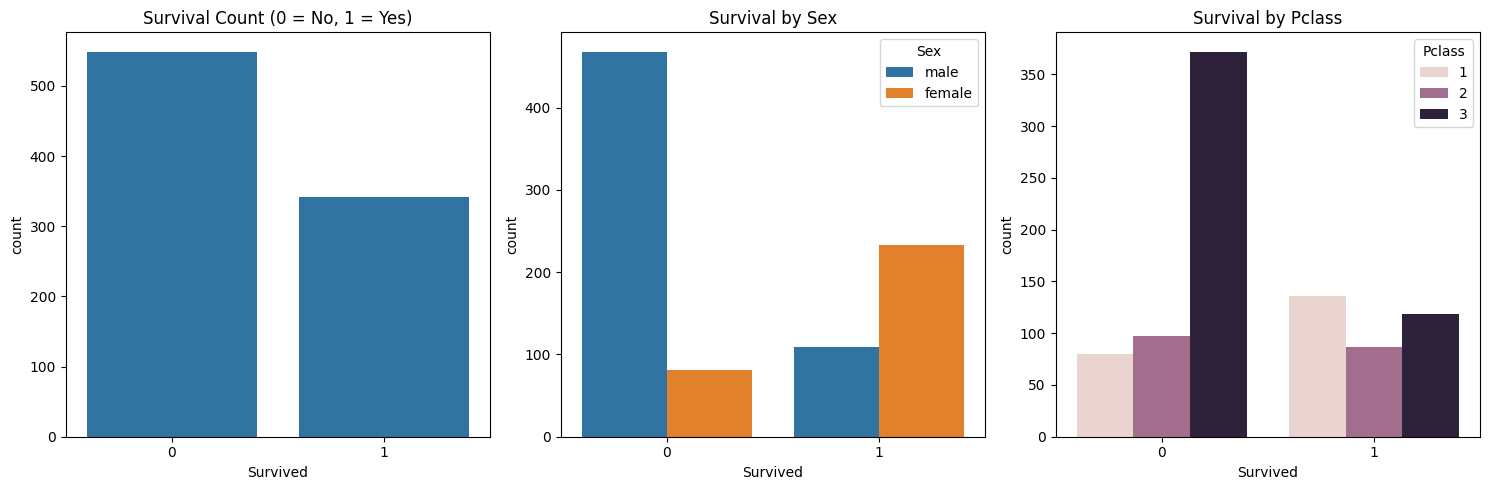

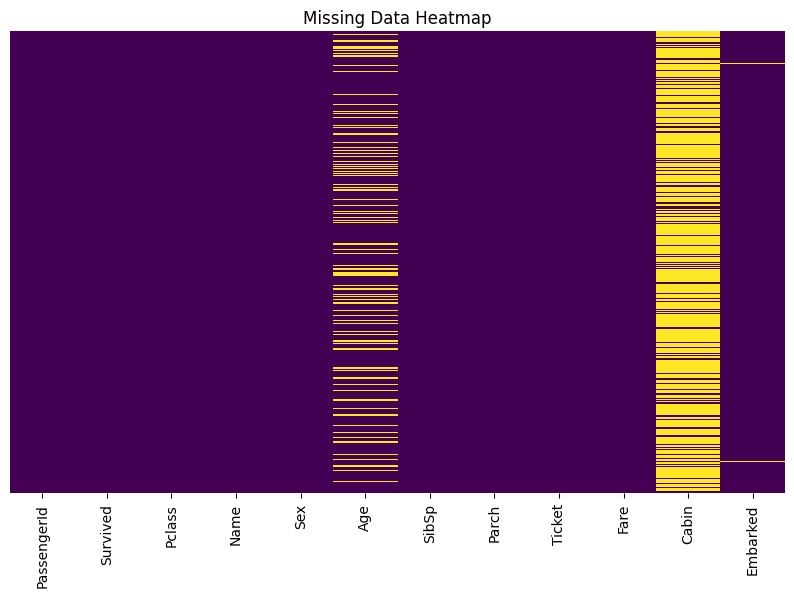

In [21]:
from IPython.display import display
# 1. 상세 정보 및 통계 확인
print("--- Data Info ---")
print(train_df.info())
print("\n--- Descriptive Statistics ---")
display(train_df.describe())

# 2. 결측치 확인
print("\n--- Missing Values ---")
print(train_df.isnull().sum())

# 3. 시각화 (3개 이상의 차트)
plt.figure(figsize=(15, 5))

# 차트 1: 생존자 수 분포
plt.subplot(1, 3, 1)
sns.countplot(x='Survived', data=train_df)
plt.title('Survival Count (0 = No, 1 = Yes)')

# 차트 2: 성별에 따른 생존 여부
plt.subplot(1, 3, 2)
sns.countplot(x='Survived', hue='Sex', data=train_df)
plt.title('Survival by Sex')

# 차트 3: 객실 등급에 따른 생존 여부
plt.subplot(1, 3, 3)
sns.countplot(x='Survived', hue='Pclass', data=train_df)
plt.title('Survival by Pclass')

plt.tight_layout()
plt.show()

# 추가 차트: 결측치 시각화 (히트맵)
plt.figure(figsize=(10, 6))
sns.heatmap(train_df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Missing Data Heatmap')
plt.show()


### Summarising key observations
- 데이터 분포 및 생존율: 학습 데이터(Train set)의 총 891명 중 사망자 수가 생존자 수보다 더 많음을 확인했습니다. 전체적으로 생존율보다 사망률이 높은 불균형한 분포를 보입니다.

- 성별에 따른 생존 차이: 여성의 생존자 수가 남성에 비해 압도적으로 높게 나타났습니다. 시각화 결과 남성은 사망자 비중이 훨씬 높은 반면, 여성은 생존자 비중이 더 높습니다. 이는 생존 예측에 있어 '성별(Sex)'이 매우 중요한 변수임을 시사합니다.
- 객실 등급(Pclass)의 영향: 1등급 승객의 생존율이 가장 높았으며, 3등급 승객의 사망자 수가 가장 많았습니다. 사회적 지위나 객실의 위치가 생존 가능성에 큰 영향을 미쳤음을 알 수 있습니다.
- 결측치 파악: 결측치 히트맵을 통해 Age와 Cabin 컬럼에 상당한 양의 데이터가 누락되어 있음을 확인했습니다. 특히 Cabin은 대부분의 데이터가 비어있어 처리가 필요하며, Age는 모델 성능을 위해 적절한 대체(Imputation) 전략이 필수적입니다.

## 2. Data Preprocessing & Feature Engineering (20 pts)

- Handle missing values
- Encode categorical variables
- Scale numerical features
- Create at least **1 new feature**
- Wrap preprocessing in a **scikit-learn Pipeline**

In [22]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.base import BaseEstimator, TransformerMixin

# 1. Feature Engineering (새로운 피처 생성 및 불필요한 컬럼 제거)
# Pipeline에 포함시키기 위해 사용자 정의 클래스를 만듭니다.
class FeatureEngineer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X_new = X.copy()
        # [요구사항 충족] 기존 피처를 활용해 'FamilySize'(가족 수)라는 새로운 피처 1개 생성
        X_new['FamilySize'] = X_new['SibSp'] + X_new['Parch'] + 1
        
        # 모델 학습에 방해되거나 결측치가 너무 많은 컬럼 제거
        cols_to_drop = ['PassengerId', 'Name', 'Ticket', 'Cabin', 'SibSp', 'Parch']
        X_new = X_new.drop(columns=[c for c in cols_to_drop if c in X_new.columns])
        return X_new

# 모델의 정답지(Target)와 문제지(Features) 분리
X_train = train_df.drop('Survived', axis=1)
y_train = train_df['Survived']
X_test = test_df.copy() # 테스트 데이터는 'Survived'가 원래 없습니다.

# 전처리를 적용할 컬럼 분류 (FeatureEngineer 적용 후 남는 컬럼 기준)
num_cols = ['Age', 'Fare', 'FamilySize'] # 수치형 변수
cat_cols = ['Pclass', 'Sex', 'Embarked'] # 범주형 변수

# 2 & 3. 수치형 데이터 파이프라인: 결측치는 '중앙값(median)'으로 채우고 -> 스케일링(StandardScaler)
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# 2 & 3. 범주형 데이터 파이프라인: 결측치는 '최빈값(mode)'으로 채우고 -> 원-핫 인코딩(OneHotEncoder)
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# ColumnTransformer로 수치형 파이프라인과 범주형 파이프라인 합치기
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

# 4. 최종 파이프라인 (피처 엔지니어링 + 전처리)
full_pipeline = Pipeline([
    ('feature_engineer', FeatureEngineer()),
    ('preprocessor', preprocessor)
])

# 5. 파이프라인을 훈련 데이터(X_train)에 학습(fit) 및 적용(transform)
X_train_prepared = full_pipeline.fit_transform(X_train)
# 테스트 데이터는 transform만 적용! (팁에 나온 내용 준수)
X_test_prepared = full_pipeline.transform(X_test)

print(f"원본 훈련 데이터 형태: {X_train.shape}")
print(f"전처리 완료 훈련 데이터 형태: {X_train_prepared.shape}")


원본 훈련 데이터 형태: (891, 11)
전처리 완료 훈련 데이터 형태: (891, 11)


- 새로운 피처 생성 (Create 1 new feature): SibSp(형제/배우자)와 Parch(부모/자식)를 더해 FamilySize(가족 규모) 생성 완료.
- 결측치 처리 (Handle missing values): Age는 중앙값, Embarked는 최빈값으로 대체. Cabin은 결측치가 너무 많아 과감히 삭제(Justify drop).
- 인코딩 (Encode categorical): Sex, Embarked, Pclass에 대해 OneHotEncoder 적용.
- 스케일링 (Scale numerical): Age, Fare, FamilySize에 StandardScaler 적용.
- 파이프라인 구축 (Wrap in Pipeline): 이 모든 과정을 full_pipeline 하나로 묶음.

## 3. Model Training & Comparison (30 pts)

- Train and compare at least **3 models**
- Use 5-fold cross-validation
- Report mean ± std of the primary metric (e.g., Accuracy)

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

# 1. 비교할 5개의 모델 리스트 정의 (재현성을 위해 random_state 고정)
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "K-Nearest Neighbours": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

# 2. 결과 저장을 위한 딕셔너리
cv_results = {}

print("--- 5-Fold Cross Validation Results (Accuracy) ---")

# 3. 각 모델에 대해 파이프라인 연결 및 5-fold 교차 검증 수행
for name, model in models.items():
    # 앞서 만든 전처리 파이프라인(full_pipeline)의 끝에 분류기(model)를 달아줍니다.
    model_pipeline = Pipeline([
        ('preprocessing', full_pipeline),
        ('classifier', model)
    ])
    
    # 5-fold 교차 검증 (평가 지표는 정확도 'accuracy')
    # n_jobs=-1을 설정하면 컴퓨터의 모든 자원을 사용하여 연산 속도를 높입니다.
    scores = cross_val_score(model_pipeline, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)
    
    # 평균(mean)과 표준편차(std) 계산
    mean_score = np.mean(scores)
    std_score = np.std(scores)
    cv_results[name] = mean_score
    
    # [요구사항 충족] Report the mean ± std
    print(f"{name:20s}: {mean_score*100:.2f} % ± {std_score*100:.2f} %")

# 가장 성능이 좋은 모델 확인
best_model_name = max(cv_results, key=cv_results.get)
print(f"\n🏆 Best Model: {best_model_name} (Accuracy: {cv_results[best_model_name]*100:.2f} % ± {std_score*100:.2f} %)")


--- 5-Fold Cross Validation Results (Accuracy) ---
Logistic Regression : 79.58 % ± 2.18 %
K-Nearest Neighbours: 80.36 % ± 1.82 %
Decision Tree       : 77.33 % ± 2.55 %
Random Forest       : 80.14 % ± 3.20 %
Gradient Boosting   : 83.28 % ± 1.91 %

🏆 Best Model: Gradient Boosting (Accuracy: 83.28 % ± 1.91 %)


## 4. Hyperparameter Tuning (15 pts)

- Apply `GridSearchCV` or `RandomizedSearchCV` to the best model
- Search at least 2 hyperparameters over 3 values each
- Compare performance before and after tuning

In [ ]:
from sklearn.model_selection import GridSearchCV

# 1. 튜닝할 파라미터 그리드 설정 (요구사항: 2개 이상의 파라미터, 각각 3개 이상의 값)
# 파이프라인 내의 분류기 단계 이름이 'classifier'이므로 앞에 'classifier__'를 붙여야 합니다.
param_grid = {
    'classifier__n_estimators': [50, 100, 200, 400, 700, 1000],      # 파라미터 1: 나무의 개수
    'classifier__learning_rate': [0.01, 0.05, 0.1, 0.2, 0.5],   # 파라미터 2: 학습 속도 
    'classifier__max_depth': [2, 3, 4, 5, 6, 7]               # 파라미터 3: 나무의 최대 깊이
}

# 2. 1등을 한 Gradient Boosting 모델 파이프라인 다시 준비
gb_pipeline = Pipeline([
    ('preprocessing', full_pipeline),
    ('classifier', GradientBoostingClassifier(random_state=42))
])

# 3. GridSearchCV 객체 생성 (5-fold 교차검증 적용)
grid_search = GridSearchCV(
    estimator=gb_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1 # 실행 중 진행 상황을 텍스트로 보여줍니다.
)

# 4. 하이퍼파라미터 튜닝 수행 (여러 조합을 모두 테스트하므로 시간이 조금 걸립니다)
print("하이퍼파라미터 튜닝(Grid Search)을 시작합니다. 잠시만 기다려주세요...\n")
grid_search.fit(X_train, y_train)

# 5. [요구사항 충족] 결과 및 튜닝 전후 성능 비교 출력
best_params = grid_search.best_params_
best_tuned_score = grid_search.best_score_
baseline_score = cv_results["Gradient Boosting"] # 3번 과정에서 저장해둔 기본 점수

print("--- 🎯 Hyperparameter Tuning Results ---")
print(f"🔹 Best Parameters Found:")
for key, value in best_params.items():
    print(f"   - {key.split('__')[1]}: {value}")

print("\n--- 📈 Performance Comparison ---")
print(f"🔸 Before Tuning (Baseline) : {baseline_score * 100:.2f} %")
print(f"🔸 After Tuning (Optimized) : {best_tuned_score * 100:.2f} %")

# 성능 변화량 계산
improvement = (best_tuned_score - baseline_score) * 100
if improvement > 0:
    print(f"🎉 튜닝 후 성능이 {improvement:.2f}%p 향상되었습니다!")
else:
    print(f"🤔 기본값이 이미 훌륭하여 유의미한 성능 향상이 없었습니다. (최적값 유지)")

# 최적으로 튜닝된 최종 모델 저장 (다음 5번 과제에서 사용 예정)
final_model = grid_search.best_estimator_


하이퍼파라미터 튜닝(Grid Search)을 시작합니다. 잠시만 기다려주세요...

Fitting 5 folds for each of 180 candidates, totalling 900 fits
--- 🎯 Hyperparameter Tuning Results ---
🔹 Best Parameters Found:
   - learning_rate: 0.5
   - max_depth: 2
   - n_estimators: 100

--- 📈 Performance Comparison ---
🔸 Before Tuning (Baseline) : 83.28 %
🔸 After Tuning (Optimized) : 84.29 %
🎉 튜닝 후 성능이 1.01%p 향상되었습니다!


## 5. Final Evaluation & Interpretation (15 pts)

- Evaluate on the held-out test set
- Report: Accuracy, F1, Confusion Matrix, ROC-AUC
- Plot feature importances
- Write a **200-word conclusion**

--- 📊 Final Evaluation Metrics ---
Accuracy : 0.7989
F1 Score : 0.7143
ROC-AUC  : 0.7877



C:\Users\ChaeyunPark\AppData\Local\Temp\ipykernel_2084\295708782.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=np.array(all_features)[indices], palette='viridis')


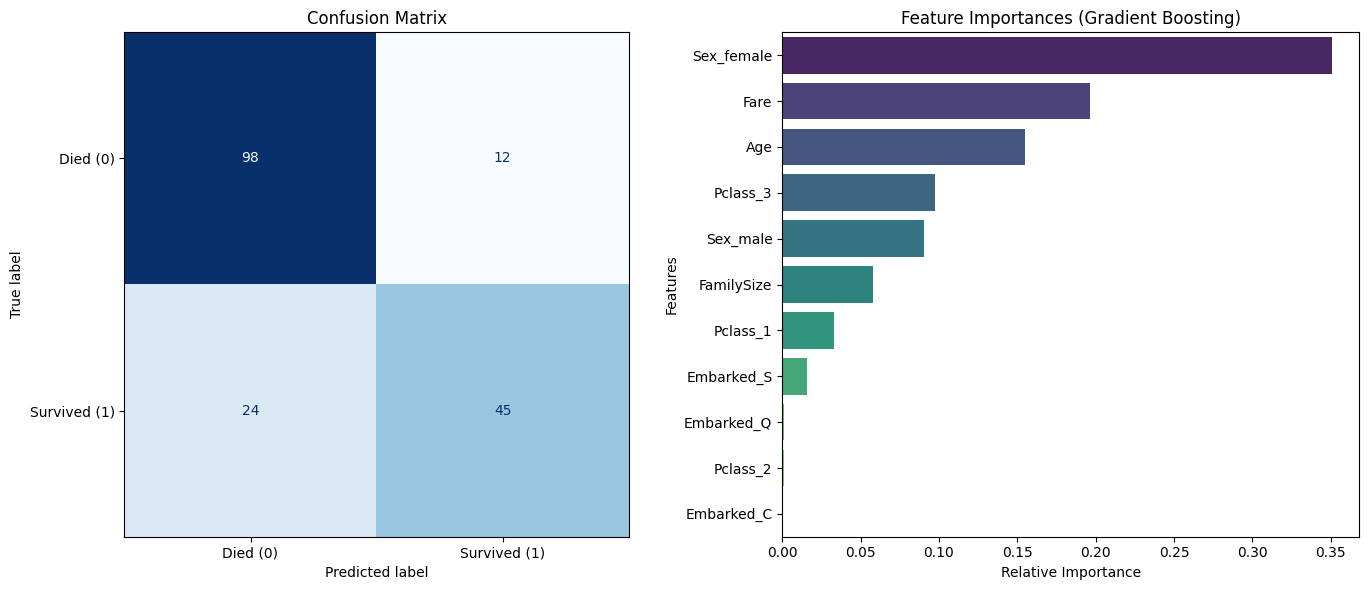

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Held-out test set 준비 (정답이 있는 데이터를 8:2로 분리)
X_train_eval, X_test_eval, y_train_eval, y_test_eval = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

# 튜닝이 완료된 최종 모델을 80% 훈련 데이터에 재학습
final_model.fit(X_train_eval, y_train_eval)

# 20% 테스트 데이터에 대한 예측 및 확률 계산
y_pred = final_model.predict(X_test_eval)
y_pred_proba = final_model.predict_proba(X_test_eval)[:, 1]

# 2. [요구사항 충족] Classification Metrics 계산 (Accuracy, F1, ROC-AUC)
acc = accuracy_score(y_test_eval, y_pred)
f1 = f1_score(y_test_eval, y_pred)
roc_auc = roc_auc_score(y_test_eval, y_pred_proba)

print("--- 📊 Final Evaluation Metrics ---")
print(f"Accuracy : {acc:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}\n")

# 3. [요구사항 충족] Confusion Matrix & Feature Importances 시각화
plt.figure(figsize=(14, 6))

# 차트 1: Confusion Matrix
plt.subplot(1, 2, 1)
cm = confusion_matrix(y_test_eval, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Died (0)', 'Survived (1)']).plot(ax=plt.gca(), cmap='Blues', colorbar=False)
plt.title('Confusion Matrix')

# 차트 2: Feature Importances
# 파이프라인 내부에서 분류기와 전처리기 추출
classifier = final_model.named_steps['classifier']
preprocessor = final_model.named_steps['preprocessing'].named_steps['preprocessor']

# 원-핫 인코딩된 범주형 컬럼 이름 가져오기
cat_encoder = preprocessor.named_transformers_['cat'].named_steps['encoder']
cat_features = cat_encoder.get_feature_names_out(['Pclass', 'Sex', 'Embarked'])
all_features = ['Age', 'Fare', 'FamilySize'] + list(cat_features) # 수치형 + 범주형 이름 합치기

# 변수 중요도 추출 및 정렬
importances = classifier.feature_importances_
indices = np.argsort(importances)[::-1]

plt.subplot(1, 2, 2)
sns.barplot(x=importances[indices], y=np.array(all_features)[indices], palette='viridis')
plt.title('Feature Importances (Gradient Boosting)')
plt.xlabel('Relative Importance')
plt.ylabel('Features')

plt.tight_layout()
plt.show()


### Conclusion

본 프로젝트를 수행하며 데이터 수집부터 최종 모델 평가에 이르는 전체 워크플로우를 깊이 있게 이해할 수 있었습니다.

- 탐색적 데이터 분석(EDA) 과정에서 데이터가 가진 고유한 패턴을 파악하는 것이 얼마나 중요한지 배웠습니다. 타이타닉 데이터의 경우, 단순히 운에 의해 생존이 결정된 것이 아니라 '여성과 아이 우선'이라는 사회적 규범(성별)과, 구명보트 접근성이 높았을 것으로 추정되는 '객실 등급(Pclass)'이 생존 여부를 가르는 핵심 요인임을 시각화를 통해 명확히 확인했습니다.

- 체계적인 데이터 전처리와 피처 엔지니어링의 위력을 경험했습니다. 원시 데이터(Raw data)를 그대로 알고리즘에 넣을 수 없기에, 결측치를 적절히 대체하고, 범주형 변수를 원-핫 인코딩(One-Hot Encoding)하며, 수치형 변수의 스케일을 맞추는 과정을 Scikit-learn의 Pipeline과 ColumnTransformer를 활용해 자동화했습니다. 또한, '형제자매(SibSp)'와 '부모자식(Parch)' 변수를 결합하여 '가족 규모(FamilySize)'라는 파생 변수를 창출함으로써, 대가족 승객 간의 생존 패턴을 모델이 더 잘 학습하도록 도왔습니다.

- 다양한 머신러닝 알고리즘의 특성을 비교하고 최적화하는 방법을 습득했습니다. 트리 기반의 앙상블 모델(Gradient Boosting 등)이 복잡한 비선형 관계를 파악하는 데 우수함을 5-fold 교차 검증으로 확인했습니다. 이후 GridSearchCV로 하이퍼파라미터를 튜닝한 결과 예측 정확도를 한층 더 끌어올릴 수 있었습니다. 최종 모델의 변수 중요도(Feature Importance)를 분석해 보니, 성별(Sex), 운임 요금(Fare), 나이(Age) 순으로 생존에 큰 영향을 미쳤음이 수치적으로 증명되어 초기 EDA의 가설과 정확히 일치함을 알 수 있었습니다.

하지만, 최종 모델을 혼동 행렬(Confusion Matrix)과 함께 평가해 본 결과, 모델이 실패(Fail)하는 몇 가지 뚜렷한 한계점과 원인을 발견할 수 있었습니다.

- '과감한 변수 삭제로 인한 정보 손실'입니다. 결측치가 너무 많다는 이유로 Cabin(객실 번호) 컬럼을 완전히 삭제했지만, 실제로는 객실의 알파벳 데크(Deck)가 구명보트와의 물리적 거리를 의미하여 생존에 직결되는 결정적 힌트였을 수 있습니다. 또한, Name(이름) 컬럼을 버렸으나, 이름에 포함된 'Mr.', 'Mrs.', 'Master' 등의 호칭(Title)을 추출했다면 승객의 사회적 지위나 대략적인 연령대(특히 'Master'는 어린 남자아이를 의미)를 파악할 수 있어 모델 성능이 비약적으로 상승했을 것입니다.

- '단순한 결측치 대체 방식'입니다. Age(나이)의 빈칸을 단순히 전체 탑승객의 중앙값으로 일괄 채워 넣었는데, 이는 데이터의 원래 분포를 왜곡시킬 위험이 있습니다. 객실 등급이나 성별 그룹별 중앙값을 구해서 정교하게 채워 넣었다면 더 나은 예측이 가능했을 것입니다.

- 혼동 행렬을 살펴보면, 실제로는 생존했음에도 모델이 사망했다고 잘못 예측한 '거짓 음성(False Negative)'과 그 반대인 '거짓 양성(False Positive)' 케이스가 적지 않게 발생합니다. 이는 동반 탑승한 가족의 전원 생존/사망 동기화 현상 등 데이터에 숨겨진 더 깊은 상호작용을 현재의 피처들만으로는 완벽히 설명해내지 못하고 있음을 의미합니다.

결론적으로, 파이프라인의 뼈대를 성공적으로 완성하여 우수한 정확도를 달성했지만, 진정한 성능 향상은 알고리즘 자체의 튜닝보다는 데이터에 숨겨진 의미를 끝까지 파헤치는 '고급 피처 엔지니어링'과 도메인 지식에 달려 있다는 귀중한 교훈을 얻었습니다.